Some plots and sanity checks of simulated data

In [646]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Get the current working directory
current_dir = os.getcwd()
# Go up one level to reach the root directory (ML4Processes)
root_dir = os.path.abspath(os.path.join(current_dir, ".."))
# Add the root directory to the Python path
if root_dir not in sys.path:
    sys.path.append(root_dir)

from utils.helper import read_json

In [ ]:
fn = 'testff50'

In [648]:
train_cvs = read_json(os.path.join(root_dir, f"event_log_simulations/at_kde_prob/{fn}/train.json"))
train_cvs_df = pd.DataFrame(train_cvs, columns = ['timestamp'])
train_cvs_df.timestamp = pd.to_datetime(train_cvs_df.timestamp, format = '%d.%m.%Y %H:%M:%S')
train_cvs_df['date'] = pd.to_datetime(train_cvs_df.timestamp.dt.date)

test_cvs = read_json(os.path.join(root_dir, f"event_log_simulations/at_kde_prob/{fn}/test.json"))
test_cvs_df = pd.DataFrame(test_cvs, columns = ['timestamp'])
test_cvs_df.timestamp = pd.to_datetime(test_cvs_df.timestamp, format = '%d.%m.%Y %H:%M:%S')
test_cvs_df['date'] = pd.to_datetime(test_cvs_df.timestamp.dt.date)

full_cvs_df = pd.concat([train_cvs_df, test_cvs_df], axis = 0, ignore_index=True)
full_cvs_df.set_index('date', inplace = True)

kde_csv = read_json(os.path.join(root_dir, f"event_log_simulations/at_kde_prob/{fn}/simulated_run_1.json"))
kde_csv_df = pd.DataFrame(kde_csv, columns = ['timestamp'])
kde_csv_df.timestamp = pd.to_datetime(kde_csv_df.timestamp, format = '%d.%m.%Y %H:%M:%S')
kde_csv_df['date'] = pd.to_datetime(kde_csv_df.timestamp.dt.date)
kde_csv_df.set_index('date', inplace=True)

output_df = pd.read_csv(os.path.join(root_dir, 'output_df.csv'), usecols = [1,2])

cluster_start_dates = output_df.groupby('predicted_cluster')['date'].first()

#sim domain 
start_date = kde_csv_df.index[0]
end_date = kde_csv_df.index[-1]

def make_weekday_time_heatmap(
    df,
    timestamp_col="timestamp",
    bin_hours=3,
    vmin_value=0,
    vmax_value=None,
    clip=False,
    title="Activity by Weekday and Time Bin"
):
    """
    Heatmap with weekdays on x-axis (1..7) and n-hour bins on y-axis.
    Colors scale from vmin_value to vmax_value (white reserved for zero counts).

    Parameters
    ----------
    df : pd.DataFrame
        Contains a datetime column `timestamp_col`.
    timestamp_col : str
        Name of the column with pandas datetime values.
    bin_hours : int
        Size of the time bins in hours (>0).
    vmin_value : int or float
        Lower bound for the colormap (e.g., 0).
    vmax_value : int or float or None
        Upper bound for the colormap (e.g., 100). If None, uses data max (excluding zeros).
    clip : bool
        If True, values are clipped to [vmin_value, vmax_value] for color scaling.
    title : str
        Figure title.

    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    counts : pd.DataFrame
        Counts table with rows = bin start hours, columns = weekdays (1..7).
    """
    if bin_hours <= 0:
        raise ValueError("bin_hours must be a positive integer.")

    ts = pd.to_datetime(df[timestamp_col], errors="coerce")
    df = df.loc[~ts.isna()].copy()
    df[timestamp_col] = ts = ts.loc[~ts.isna()]

    # Monday=0..Sunday=6 -> 1..7
    df["weekday"] = ts.dt.dayofweek + 1

    # Bin assignment
    minutes = ts.dt.hour * 60 + ts.dt.minute
    step_min = bin_hours * 60
    bin_start_hour = ((minutes // step_min) * bin_hours).astype(int)
    bin_start_hour = bin_start_hour.clip(0, 24 - bin_hours)
    df["bin_start_hour"] = bin_start_hour

    weekdays = np.arange(1, 8)                 # 1..7
    bins = np.arange(0, 24, bin_hours, int)    # 0, bin_hours, ...

    counts = (
        df.groupby(["bin_start_hour", "weekday"])
          .size()
          .unstack("weekday")
          .reindex(index=bins, columns=weekdays, fill_value=0)
    )

    data = counts.values
    # Mask zero counts to keep them pure white
    masked = np.ma.masked_where(data == 0, data)

    # Determine vmax default (exclude zeros, fallback to vmin if all zeros)
    if vmax_value is None:
        nonzero_max = data[data > 0].max() if (data > 0).any() else vmin_value or 1
        vmax_value = nonzero_max

    if vmin_value >= vmax_value:
        raise ValueError("vmin_value must be strictly less than vmax_value.")

    # Optional clipping for display normalization
    if clip:
        masked = np.ma.masked_where(data == 0, np.clip(data, vmin_value, vmax_value))

    cmap = plt.cm.Reds.copy()
    cmap.set_bad(color="white")  # masked (zeros) -> white

    fig, ax = plt.subplots(figsize=(8, 5), dpi=140)
    im = ax.imshow(
        masked,
        aspect="auto",
        origin="lower",
        cmap=cmap,
        vmin=vmin_value,
        vmax=vmax_value
    )

    # Per-cell gridlines
    nrows, ncols = counts.shape
    ax.set_xticks(np.arange(-0.5, ncols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, nrows, 1), minor=True)
    ax.grid(which="minor", color="#808080", linestyle="-", linewidth=0.9)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.grid(False, which="major")

    # Axis ticks & labels
    ax.set_xticks(np.arange(ncols))
    ax.set_xticklabels(weekdays)

    def fmt_bin(h):
        end = min(h + bin_hours, 24)
        return f"{h:02d}–{end:02d}"

    ax.set_yticks(np.arange(nrows))
    ax.set_yticklabels([fmt_bin(h) for h in bins])

    ax.set_xlabel("Weekday (Mon=1 … Sun=7)")
    ax.set_ylabel(f"{bin_hours}-hour bin")
    ax.set_title(title)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Count of timestamps")

    plt.tight_layout()
    return fig, ax, counts

#Created based on make_weekday_time_heatmap a heatmap method with 30min steps with Perplexity
def make_weekday_time_heatmap_30min(
    df,
    timestamp_col="timestamp",
    bin_minutes=30,
    vmin_value=0,
    vmax_value=None,
    clip=False,
    title="Activity by Weekday and Time Bin"
):
    """
    Heatmap with weekdays on x-axis (1..7) and time bins on y-axis.
    Colors scale from vmin_value to vmax_value (white reserved for zero counts).
    """
    if bin_minutes <= 0:
        raise ValueError("bin_minutes must be a positive integer.")
    if 1440 % bin_minutes != 0:
        raise ValueError("bin_minutes must divide 24 hours evenly, e.g. 30, 60, 120.")

    ts = pd.to_datetime(df[timestamp_col], errors="coerce")
    df = df.loc[~ts.isna()].copy()
    df[timestamp_col] = ts = ts.loc[~ts.isna()]

    # Monday=0..Sunday=6 -> 1..7
    df["weekday"] = ts.dt.dayofweek + 1

    # Bin assignment in minutes since midnight
    minutes = ts.dt.hour * 60 + ts.dt.minute
    bin_start_min = ((minutes // bin_minutes) * bin_minutes).astype(int)
    bin_start_min = bin_start_min.clip(0, 1440 - bin_minutes)
    df["bin_start_min"] = bin_start_min

    weekdays = np.arange(1, 8)
    bins = np.arange(0, 1440, bin_minutes)

    counts = (
        df.groupby(["bin_start_min", "weekday"])
          .size()
          .unstack("weekday")
          .reindex(index=bins, columns=weekdays, fill_value=0)
    )

    data = counts.values
    masked = np.ma.masked_where(data == 0, data)

    if vmax_value is None:
        nonzero_max = data[data > 0].max() if (data > 0).any() else (vmin_value or 1)
        vmax_value = nonzero_max

    if vmin_value >= vmax_value:
        raise ValueError("vmin_value must be strictly less than vmax_value.")

    if clip:
        masked = np.ma.masked_where(data == 0, np.clip(data, vmin_value, vmax_value))

    cmap = plt.cm.Reds.copy()
    cmap.set_bad(color="white")

    fig, ax = plt.subplots(figsize=(8, 10), dpi=140)
    im = ax.imshow(
        masked,
        aspect="auto",
        origin="lower",
        cmap=cmap,
        vmin=vmin_value,
        vmax=vmax_value
    )

    nrows, ncols = counts.shape
    ax.set_xticks(np.arange(-0.5, ncols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, nrows, 1), minor=True)
    ax.grid(which="minor", color="#808080", linestyle="-", linewidth=0.6)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.grid(False, which="major")

    ax.set_xticks(np.arange(ncols))
    ax.set_xticklabels(weekdays)

    def fmt_bin(m):
        end = min(m + bin_minutes, 1440)
        h1, m1 = divmod(m, 60)
        h2, m2 = divmod(end, 60)
        return f"{h1:02d}:{m1:02d}–{h2:02d}:{m2:02d}"

    ax.set_yticks(np.arange(nrows))
    ax.set_yticklabels([fmt_bin(m) for m in bins])

    ax.set_xlabel("Weekday (Mon=1 … Sun=7)")
    ax.set_ylabel(f"{bin_minutes}-minute bin")
    ax.set_title(title)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Count of timestamps")

    plt.tight_layout()
    return fig, ax, counts


File correctly read: /Users/chuvii/Desktop/xAT-KDE-prod/AT-KDE-/event_log_simulations/at_kde_prob/testff50/train.json.
File correctly read: /Users/chuvii/Desktop/xAT-KDE-prod/AT-KDE-/event_log_simulations/at_kde_prob/testff50/test.json.
File correctly read: /Users/chuvii/Desktop/xAT-KDE-prod/AT-KDE-/event_log_simulations/at_kde_prob/testff50/simulated_run_1.json.


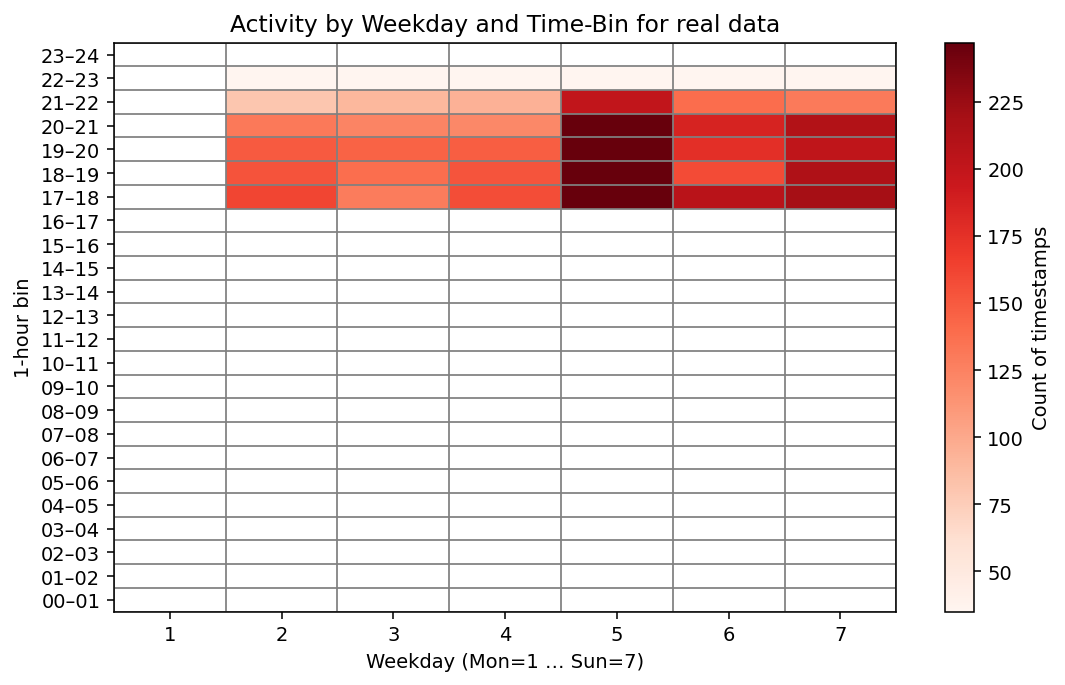

In [649]:
fig, ax, counts = make_weekday_time_heatmap(full_cvs_df.loc[start_date:end_date], 
                                            "timestamp", 
                                            bin_hours=1, 
                                            vmin_value=full_cvs_df.loc[start_date:end_date].groupby('date').agg('count').min()[0], 
                                            vmax_value=full_cvs_df.loc[start_date:end_date].groupby('date').agg('count').max()[0], 
                                            title='Activity by Weekday and Time-Bin for real data')
plt.show()

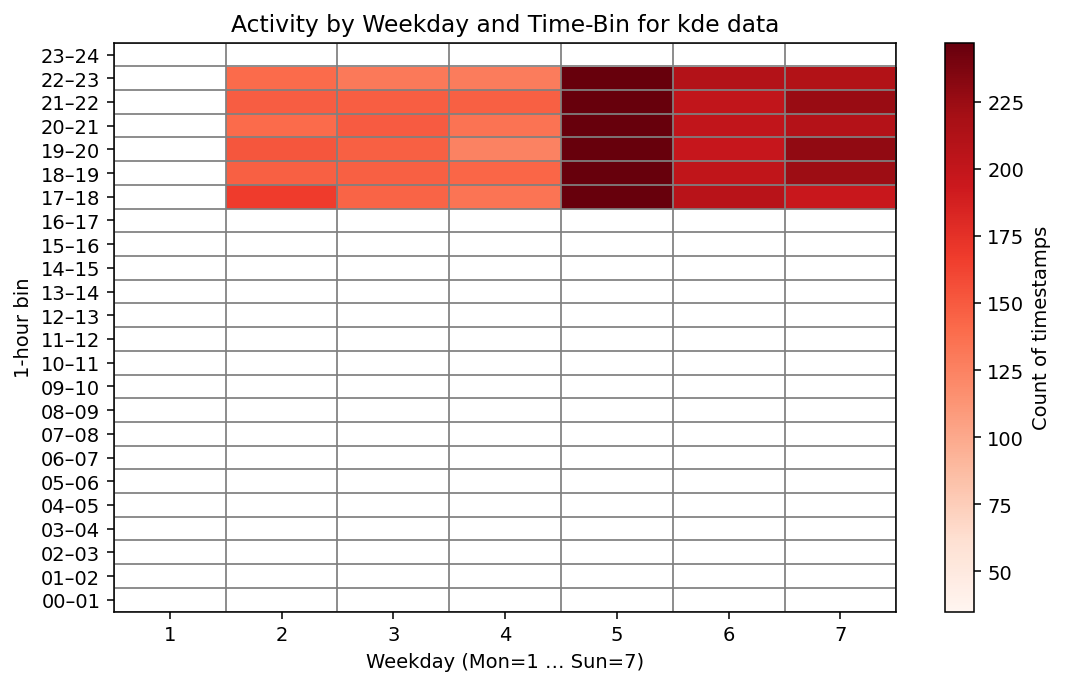

In [650]:
fig, ax, counts = make_weekday_time_heatmap(kde_csv_df, 
                                            "timestamp", 
                                            bin_hours=1, 
                                            vmin_value=full_cvs_df.loc[start_date:end_date].groupby('date').agg('count').min()[0], 
                                            vmax_value=full_cvs_df.loc[start_date:end_date].groupby('date').agg('count').max()[0], 
                                            title='Activity by Weekday and Time-Bin for kde data')
plt.show()

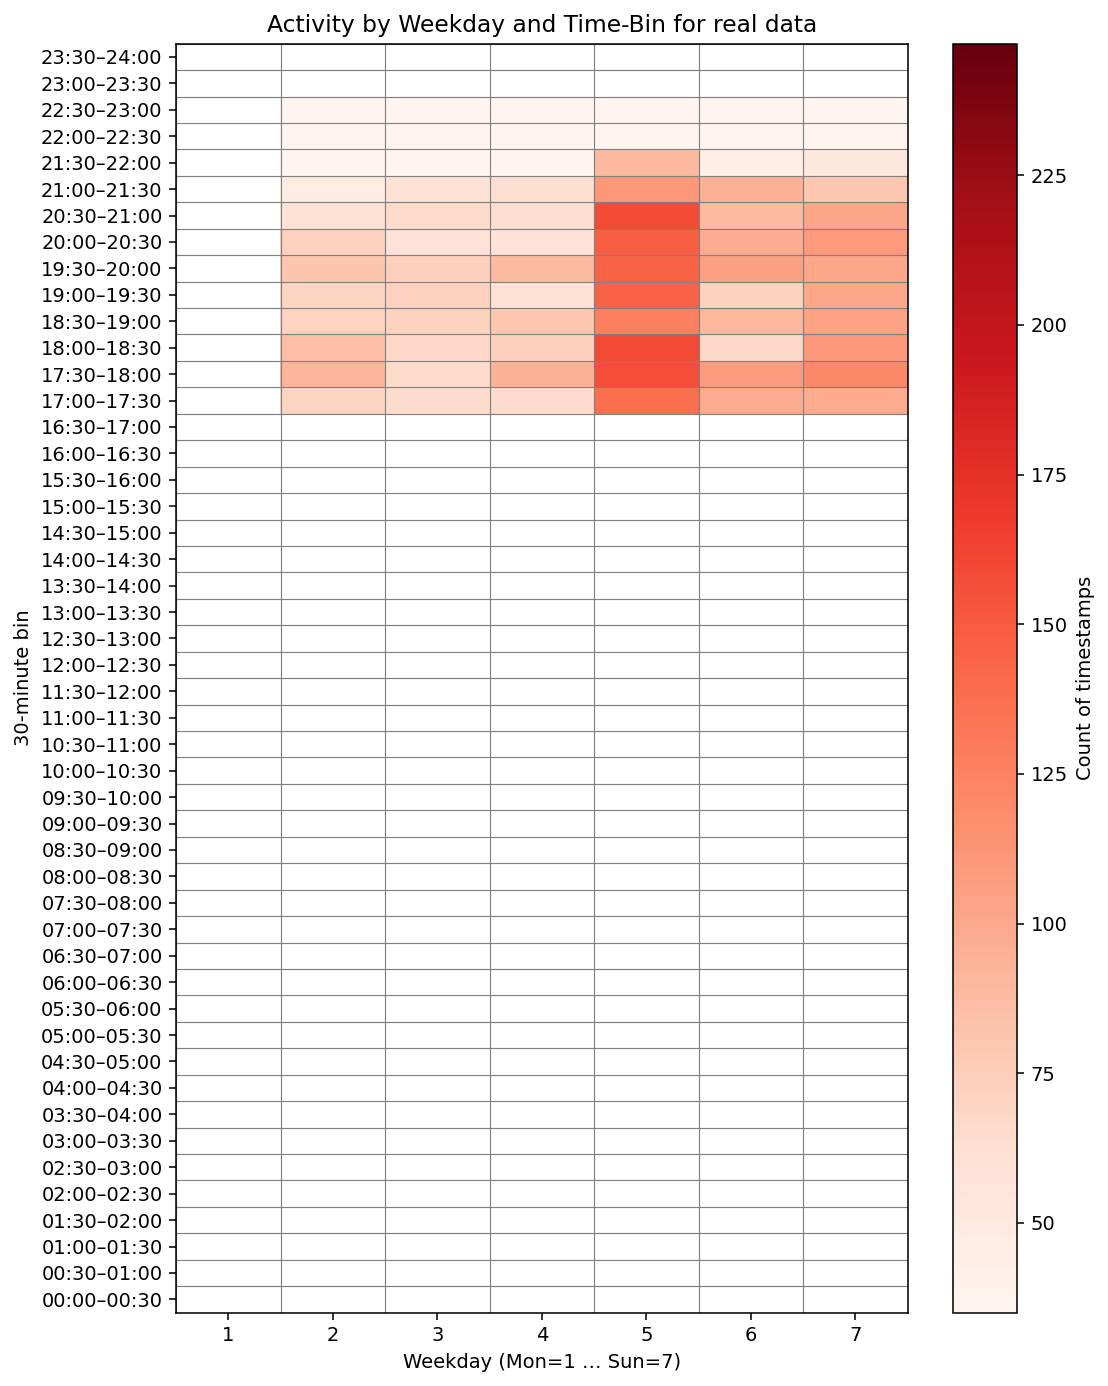

In [651]:
fig, ax, counts = make_weekday_time_heatmap_30min(full_cvs_df.loc[start_date:end_date], 
                                            "timestamp", 
                                            bin_minutes=30, 
                                            vmin_value=full_cvs_df.loc[start_date:end_date].groupby('date').agg('count').min()[0], 
                                            vmax_value=full_cvs_df.loc[start_date:end_date].groupby('date').agg('count').max()[0], 
                                            title='Activity by Weekday and Time-Bin for real data')
plt.show()

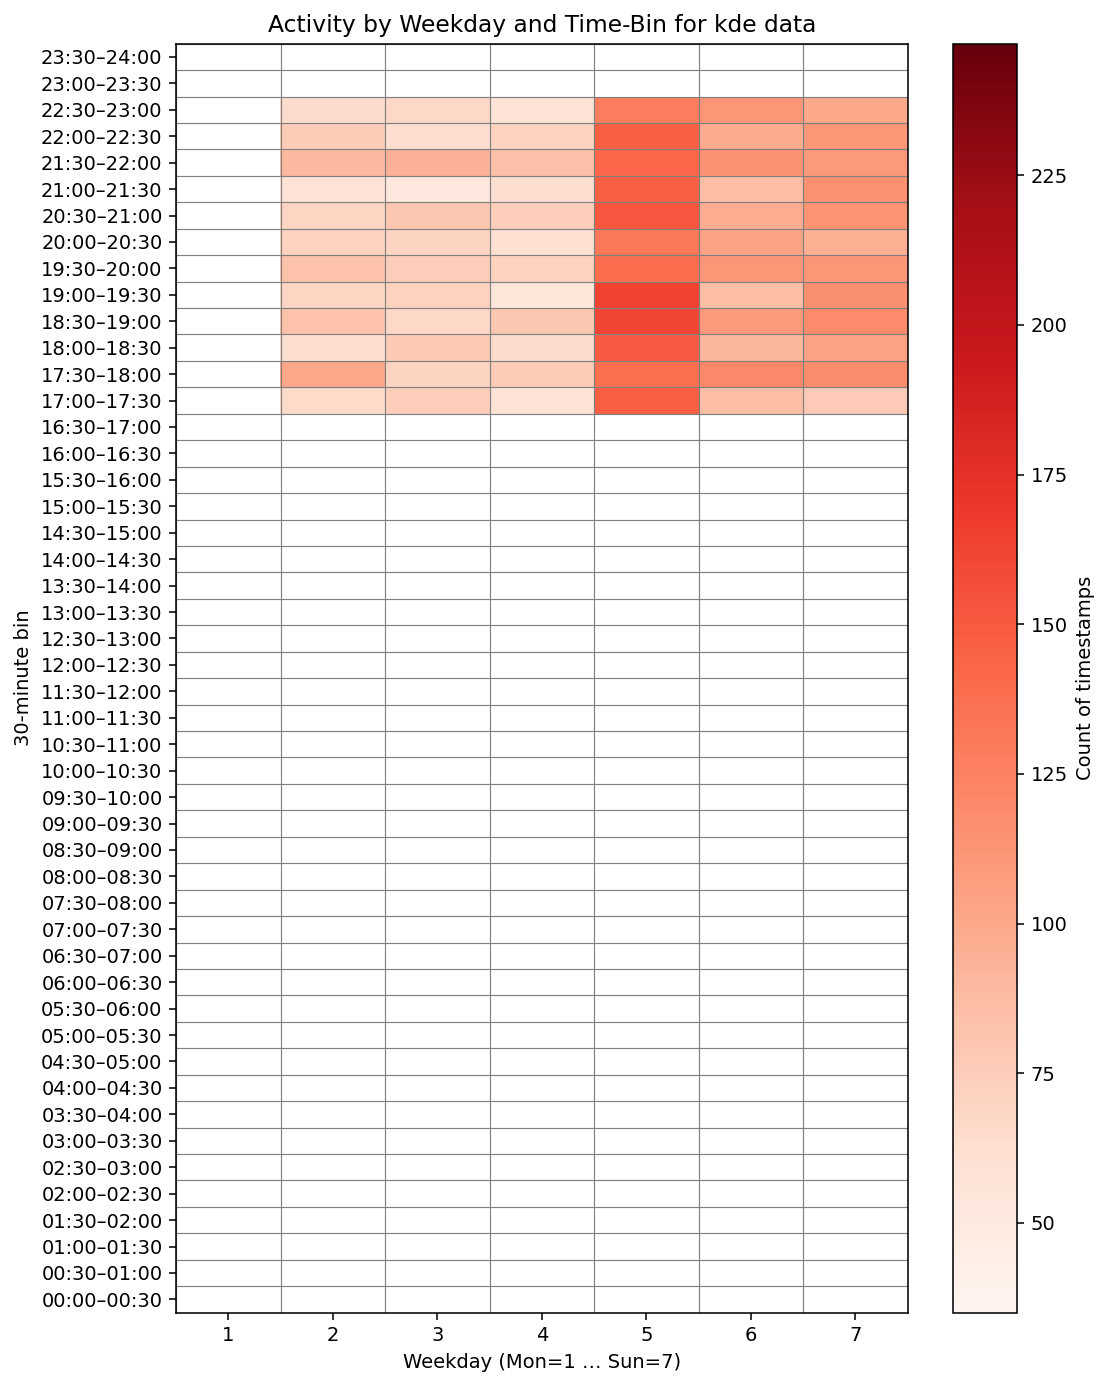

In [652]:
fig, ax, counts = make_weekday_time_heatmap_30min(kde_csv_df, 
                                            "timestamp", 
                                            bin_minutes=30, 
                                            vmin_value=full_cvs_df.loc[start_date:end_date].groupby('date').agg('count').min()[0], 
                                            vmax_value=full_cvs_df.loc[start_date:end_date].groupby('date').agg('count').max()[0], 
                                            title='Activity by Weekday and Time-Bin for kde data')
plt.show()

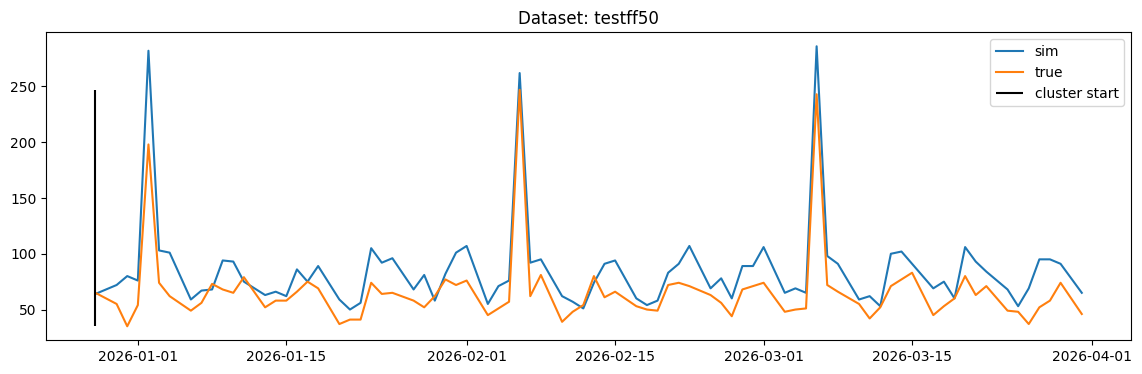

In [653]:
plt.figure(figsize=(14,4))
plt.title(f'Dataset: {fn}')
plt.plot(kde_csv_df.groupby('date').agg('count'), label = 'sim')
plt.plot(full_cvs_df.loc[start_date:end_date].groupby('date').agg('count'), label = 'true')
plt.vlines(cluster_start_dates, full_cvs_df.loc[start_date:end_date].groupby('date').agg('count').min(), full_cvs_df.loc[start_date:end_date].groupby('date').agg('count').max(), color = 'black', label = 'cluster start')
plt.legend()
plt.show()

In [654]:
##################

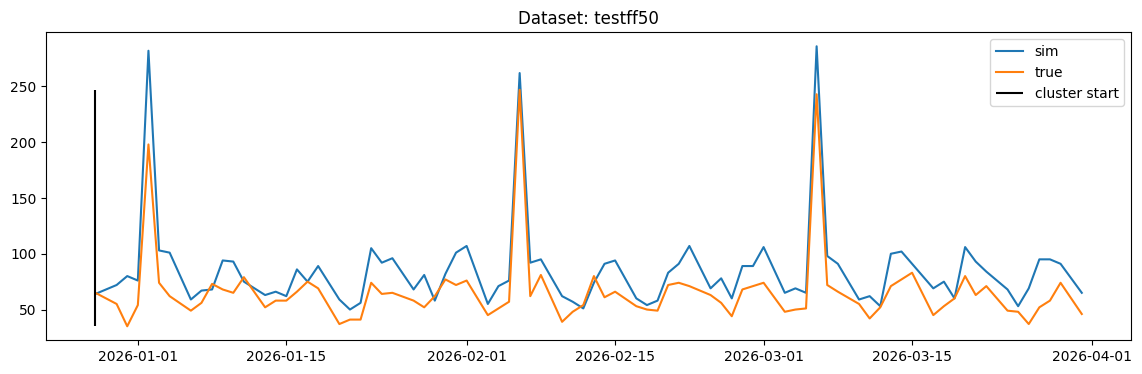

In [655]:
#new full train
plt.figure(figsize=(14,4))
plt.title(f'Dataset: {fn}')
plt.plot(kde_csv_df.groupby('date').agg('count'), label = 'sim')
plt.plot(full_cvs_df.loc[start_date:end_date].groupby('date').agg('count'), label = 'true')
plt.vlines(cluster_start_dates, full_cvs_df.loc[start_date:end_date].groupby('date').agg('count').min(), full_cvs_df.loc[start_date:end_date].groupby('date').agg('count').max(), color = 'black', label = 'cluster start')
plt.legend()
plt.show()

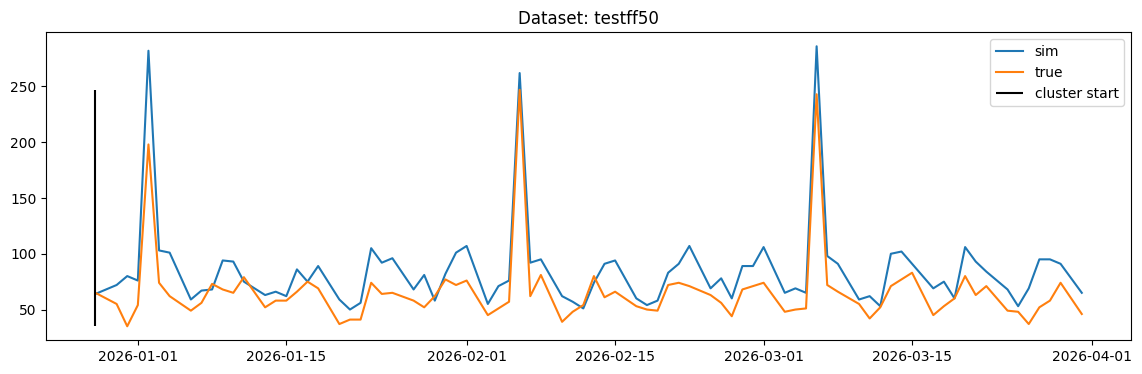

In [656]:
#old full train
plt.figure(figsize=(14,4))
plt.title(f'Dataset: {fn}')
plt.plot(kde_csv_df.groupby('date').agg('count'), label = 'sim')
plt.plot(full_cvs_df.loc[start_date:end_date].groupby('date').agg('count'), label = 'true')
plt.vlines(cluster_start_dates, full_cvs_df.loc[start_date:end_date].groupby('date').agg('count').min(), full_cvs_df.loc[start_date:end_date].groupby('date').agg('count').max(), color = 'black', label = 'cluster start')
plt.legend()
plt.show()